In [260]:
from pathlib import Path
notebook_dir = Path().resolve()
data_path = notebook_dir.parent / 'therapy_recovery_clean.csv'
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import statsmodels.formula.api as smf
from scipy import stats
from sklearn.model_selection import train_test_split
from statsmodels.stats.anova import anova_lm

In [262]:
data = pd.read_csv(data_path).drop(columns=['patient_id', 'discharge_date', 'discharge_date_fix'])

data

,therapy,sex,age_years,age_band,comorbidity,admit_date,los_final_days
0,std,F,49,40-64 歲,mild,2025-04-07,13
1,std,F,60,40-64 歲,none,2025-05-11,11
2,new,F,76,65 歲以上,mild,2025-04-09,8
3,new,M,53,40-64 歲,mild,2025-04-27,12
4,std,F,18,<40 歲,severe,2025-01-12,15
...,...,...,...,...,...,...,...
195,new,M,62,40-64 歲,mild,2025-04-05,11
196,std,F,74,65 歲以上,mild,2025-04-22,13
197,std,F,48,40-64 歲,none,2025-02-07,6
198,std,F,29,<40 歲,mild,2025-05-08,12


---
---

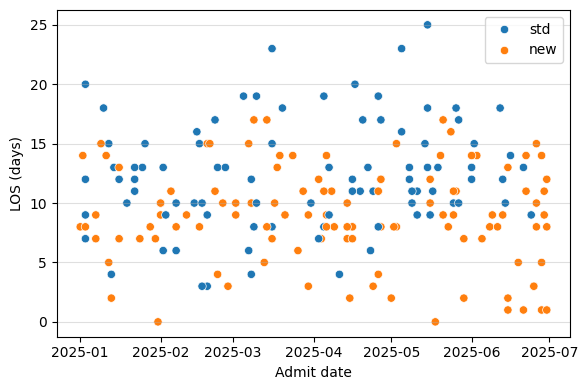

In [278]:
# Parse
data["admit_date"] = pd.to_datetime(data['admit_date'], errors="coerce")
plot_df = data.loc[:, ["admit_date", 'los_final_days', 'therapy']]

# Plot
plt.figure(figsize=(6, 4))
sns.scatterplot(data=plot_df, x="admit_date", y='los_final_days', hue='therapy', hue_order=['std', 'new'])
plt.xlabel("Admit date")
plt.ylabel("LOS (days)")
plt.grid(axis="y", alpha=0.4)
# plt.axhline(y=15, color='r', linestyle='--', label='Target: 15days')
plt.legend()
plt.tight_layout()
plt.show()


In [277]:
data.groupby('therapy')['los_final_days'].describe()

,count,mean,std,min,25%,50%,75%,max
therapy,,,,,,,,
new,112.0,8.928571,4.112636,0.0,7.00,9.0,11.25,17.0
std,88.0,12.420455,4.640456,3.0,9.75,12.0,15.00,25.0


<Axes: xlabel='therapy', ylabel='los_final_days'>

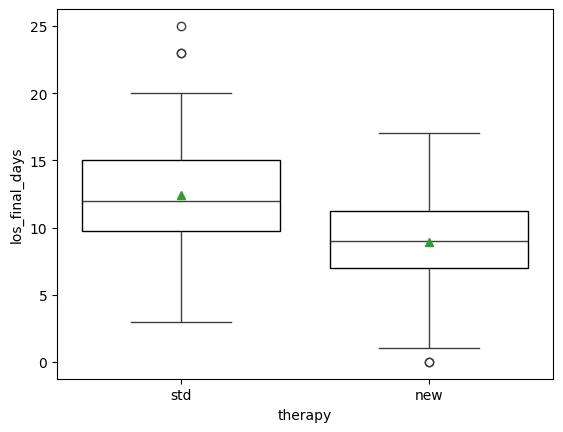

In [275]:
sns.boxplot(data, x='therapy', y='los_final_days', showmeans=True, boxprops=dict(facecolor='none', edgecolor='black'))

### 新舊療法 T-test

In [265]:
lfd_new = data.loc[data['therapy']=='new', 'los_final_days']
lfd_std = data.loc[data['therapy']=='std', 'los_final_days']

t_stat, p_val = stats.ttest_ind(lfd_new, lfd_std, equal_var=False)

mean_new, mean_std = lfd_new.mean(), lfd_std.mean()
diff = mean_new-mean_std

s1, s2 = lfd_new.std(ddof=1), lfd_std.std(ddof=1)
n1, n2 = len(lfd_new), len(lfd_std)
se_diff = np.sqrt((s1**2/n1)+(s2**2/n2))
df_welch = ((s1**2/n1+s2**2/n2)**2)/((s1**4/(n1**2*(n1-1)))+(s2**4/(n2**2*(n2-1))))
t_crit = stats.t.ppf(0.975, df_welch)
ci_low = diff-t_crit*se_diff
ci_up = diff+t_crit*se_diff
print(f"Mean(std) = {mean_std:.4f} days")
print(f"Mean(new) = {mean_new:.4f} days")
print(f"平均差異 Δ = {diff:.4f} 天 (new − std)")
print(f"95% CI = [{ci_low:.4f}, {ci_up:.4f}]")
print(f"t = {t_stat:.4f}, data = {df_welch:.1f}, p = {p_val:.4f}")

Mean(std) = 12.4205 days
Mean(new) = 8.9286 days
平均差異 Δ = -3.4919 天 (new − std)
95% CI = [-4.7334, -2.2504]
t = -5.5509, data = 175.2, p = 0.0000


### 結果 I

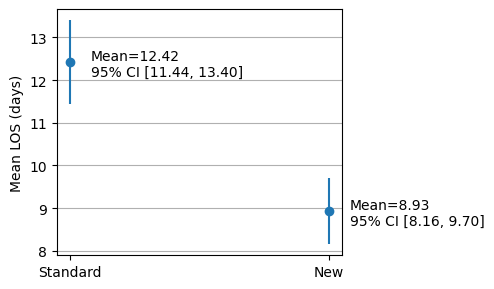

In [266]:
# === 每組平均與95% CI ===
summary = (data.groupby('therapy')['los_final_days'].agg(n="count", mean="mean", sd=lambda s: s.std(ddof=1)).reset_index())

# t臨界值與CI半寬
summary["se"] = summary["sd"] / np.sqrt(summary["n"])
summary["tcrit"] = summary.apply(lambda r: stats.t.ppf(0.975, df=int(r["n"]-1)), axis=1)
summary["ci_half"] = summary["tcrit"] * summary["se"]
summary["ci_low"] = summary["mean"] - summary["ci_half"]
summary["ci_up"]  = summary["mean"] + summary["ci_half"]

# 固定順序：std, new
order = ["std", "new"]
plot_df = summary.set_index('therapy').loc[order].reset_index()

# === Welch 差異與其95% CI（new - std）===
m_new, m_std = plot_df.loc[plot_df['therapy']=="new","mean"].item(), plot_df.loc[plot_df['therapy']=="std","mean"].item()
s_new, s_std = plot_df.loc[plot_df['therapy']=="new","sd"].item(),   plot_df.loc[plot_df['therapy']=="std","sd"].item()
n_new, n_std = plot_df.loc[plot_df['therapy']=="new","n"].item(),    plot_df.loc[plot_df['therapy']=="std","n"].item()

# === 畫圖（點估計 ± 95% CI）===
fig, ax = plt.subplots(figsize=(5, 3))
x = np.arange(len(order))
y = plot_df["mean"].values
yerr = plot_df["ci_half"].values

ax.errorbar(x, y, yerr=yerr, fmt='o')
ax.set_xticks(x)
ax.set_xticklabels(["Standard", "New"])
ax.set_ylabel("Mean LOS (days)")
ax.grid(axis='y')
# === 在圖上標出「平均值與 95% CI」文字 ===
for xi, m, lo, up in zip(x, plot_df["mean"], plot_df["ci_low"], plot_df["ci_up"]):
    label = f"Mean={m:.2f}\n95% CI [{lo:.2f}, {up:.2f}]"
    ax.annotate(label,
                (xi, m),
                textcoords="offset points",
                xytext=(15, -10),  # 文字相對於點往上 12px
                ha="left")
    
plt.tight_layout()
plt.show()

---
---

### ANOVA

In [263]:
data['age_band'] = data['age_band'].replace({'40-64 歲':'middle', '65 歲以上':'old', '<40 歲':'young'})

df = data.loc[:, ['therapy', 'comorbidity', 'los_final_days', 'age_band']].dropna().copy()
df['therapy'] = pd.Categorical(df['therapy'], categories=['std', 'new'])
df['comorbidity'] = pd.Categorical(df['comorbidity'], categories=['none', 'mild', 'severe'])
df['age_band'] = pd.Categorical(df['age_band'], categories=['young', 'middle', 'old'])

# 1) 先做含交互作用的二因子 ANOVA
mod_full = smf.ols('los_final_days ~ C(therapy) * C(comorbidity) * C(age_band)', data=df).fit()
anova_full = anova_lm(mod_full, typ=2)   # typ=2 常用；你也可改 typ=3
print(anova_full)

                                            sum_sq     df          F  \
C(therapy)                              510.489592    1.0  36.158095   
C(comorbidity)                          890.436442    2.0  31.534909   
C(age_band)                              28.649347    2.0   1.014620   
C(therapy):C(comorbidity)                 0.313040    2.0   0.011086   
C(therapy):C(age_band)                   17.509906    2.0   0.620115   
C(comorbidity):C(age_band)              138.476796    4.0   2.452086   
C(therapy):C(comorbidity):C(age_band)   116.482752    4.0   2.062625   
Residual                               2583.642616  183.0        NaN   

                                             PR(>F)  
C(therapy)                             9.664750e-09  
C(comorbidity)                         1.707796e-12  
C(age_band)                            3.645704e-01  
C(therapy):C(comorbidity)              9.162596e-01  
C(therapy):C(age_band)                 5.390088e-01  
C(comorbidity):C(age_band) 

c:\Users\USER\anaconda3\Lib\site-packages\statsmodels\base\model.py:1894: ValueWarning: covariance of constraints does not have full rank. The number of constraints is 2, but rank is 1
  warnings.warn('covariance of constraints does not have full '


### 結果 II

C:\Users\USER\AppData\Local\Temp\ipykernel_25144\2305605487.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  g = df.groupby(["age_band", "comorbidity"])["los_final_days"]


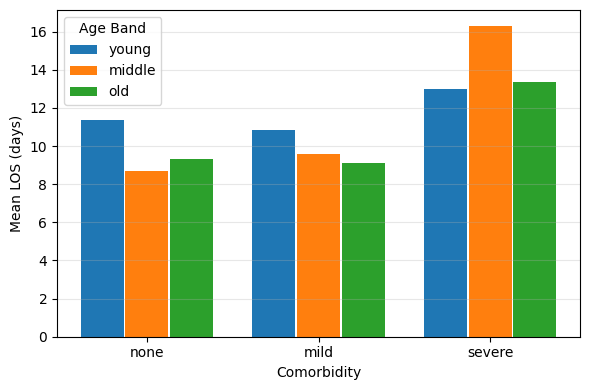

In [264]:
# 4) Summaries: mean, count, sd, se, 95% CI
g = df.groupby(["age_band", "comorbidity"])["los_final_days"]
summary = g.agg(mean="mean", sd="std", n="count").reset_index()
summary["se"] = summary["sd"] / np.sqrt(summary["n"].replace(0, np.nan))
summary["ci95"] = 1.96 * summary["se"]
summary["lower95"] = summary["mean"] - summary["ci95"]
summary["upper95"] = summary["mean"] + summary["ci95"]

# 5) Bar chart with 95% CI
age_levels = ['young', 'middle', 'old']
cb_levels = ['none', 'mild', 'severe']

x = np.arange(len(cb_levels))

fig1, ax1 = plt.subplots(figsize=(6, 4))
for j, age in enumerate(age_levels):
    sub = summary[summary["age_band"] == age]
    means = []
    errs = []
    for cb in cb_levels:
        row = sub[sub["comorbidity"] == cb]
        means.append(float(row["mean"].iloc[0]))
    positions = x + (j - (len(age_levels)-1)/2) * 0.26
    ax1.bar(x=positions, height=means, width=0.25, label=age, capsize=4)
    
ax1.set_xlabel("Comorbidity")
ax1.set_ylabel("Mean LOS (days)")
ax1.set_xticks(x)
ax1.set_xticklabels(cb_levels)
ax1.legend(title="Age Band")
ax1.grid(axis="y", alpha=0.3)
fig1.tight_layout()